In [19]:
variante = "rgb"                   # rgb nb contours
normalisation = "normalisee"      #normalisee non_normalisee
gamma = 0.0001                      # largeur gaussiennes phi = e^(-gamma * distance^2)
nb_centres = 400                  # K  kmeans 200
seed = 67                    
mode = "rosenblatt"               
epochs = 300                      # pour roseblatt
lr = 0.01                          # idem 



In [20]:
# compile rbf.cpp & lance
import subprocess
from pathlib import Path


racine = Path.cwd()
while racine != racine.parent and not (racine / "preprocessing").exists():
    racine = racine.parent

dossier_rbf = racine / "models" / "rbf"
chemin_cpp = dossier_rbf / "rbf.cpp"
chemin_exec = dossier_rbf / "rbf"

# -I dossier_rbf pour trouver eigen-5.0.0, -O2 sinon c'est trop lent hihi 
subprocess.check_call(["g++", "-O2", "-std=c++17", str(chemin_cpp), "-o", str(chemin_exec), "-I", str(dossier_rbf)], cwd=str(racine))

def lancer_rbf(variante, normalisation, gamma, nb_centres, seed, mode="rosenblatt", epochs=100, lr=0.1):
    base = racine / "datasets" / "transformed" / variante / normalisation
    cmd = [
        str(chemin_exec),
        str(base / "X_train.f32bin"), str(base / "y_train.i32bin"),
        str(base / "X_test.f32bin"), str(base / "y_test.i32bin"),
        str(gamma), str(nb_centres), str(seed),
        mode, str(epochs), str(lr),
    ]
    return subprocess.check_output(cmd, text=True, cwd=str(racine))

sortie = lancer_rbf(variante, normalisation, gamma, nb_centres, seed, mode, epochs, lr)

for ligne in sortie.splitlines():
    if not ligne.startswith("kmeans iteration") and not ligne.startswith("epoch"):
        print(ligne)

Chargé train: n=1200, d=49152
Chargé test : n=301, d=49152
Entraînement RBF kmeans + Rosenblatt, gamma=0.0001, nb_centres=400, seed=67, epochs=300, lr=0.01
pocket epoch 279 train 0.643
acc train 0.643
acc test 0.635
confusion
55 30 13
16 73 17
12 22 63


In [21]:
def parser_sortie(sortie):
    acc_train = None
    acc_test = None
    confusion = None
    epochs_train = []   # courbe par epoch 
    epochs_test = []
    lignes = sortie.strip().splitlines()
    for i, ligne in enumerate(lignes):
        if ligne.startswith("epoch"):
            morceaux = ligne.split()   # epoch <e> train <acc> test <acc>
            epochs_train.append(float(morceaux[3]))
            epochs_test.append(float(morceaux[5]))
        if ligne.startswith("acc train"):
            acc_train = float(ligne.split()[2])
        if ligne.startswith("acc test"):
            acc_test = float(ligne.split()[2])
        if ligne.strip() == "confusion":
            confusion = [[int(x) for x in lignes[i + 1 + j].split()] for j in range(3)]
    return acc_train, acc_test, confusion, epochs_train, epochs_test

acc_train, acc_test, confusion, epochs_train, epochs_test = parser_sortie(sortie)
print("acc train:", acc_train)
print("acc test :", acc_test)
print("confusion:", confusion)
print("nb epochs effectues:", len(epochs_train))

acc train: 0.643
acc test : 0.635
confusion: [[55, 30, 13], [16, 73, 17], [12, 22, 63]]
nb epochs effectues: 300


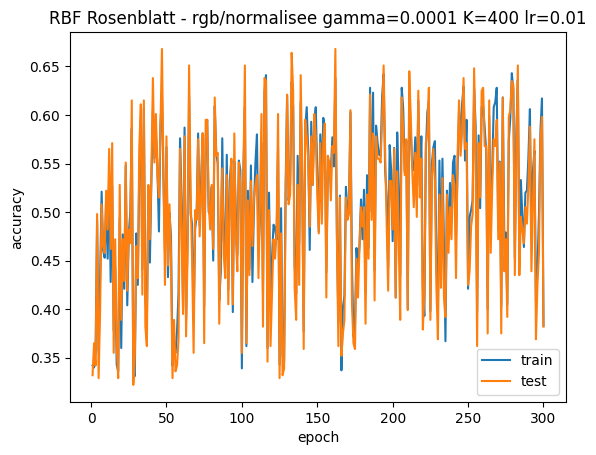

In [22]:
# courbe train/test par epoch (ros)
# si le train monte et que le test stagne bah surapprentissage
import matplotlib.pyplot as plt

if epochs_train:
    plt.plot(range(1, len(epochs_train) + 1), epochs_train, label="train")
    plt.plot(range(1, len(epochs_test) + 1), epochs_test, label="test")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(f"RBF Rosenblatt - {variante}/{normalisation} gamma={gamma} K={nb_centres} lr={lr}")
    plt.legend()
    plt.show()
else:
    print(" pas d'epochs")

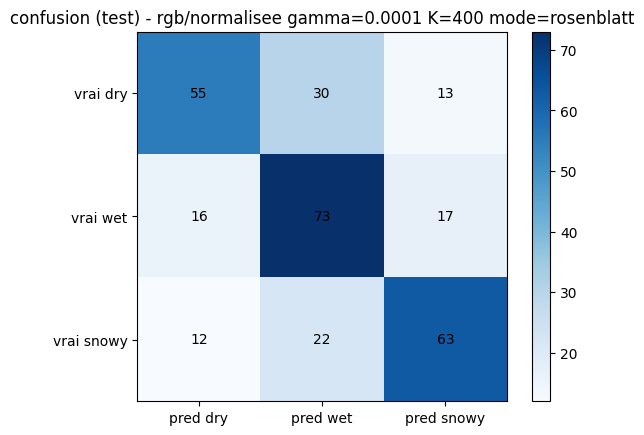

In [23]:
# matrice confusion test
import matplotlib.pyplot as plt

plt.imshow(confusion, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1, 2], ["pred dry", "pred wet", "pred snowy"])
plt.yticks([0, 1, 2], ["vrai dry", "vrai wet", "vrai snowy"])
for i in range(3):
    for j in range(3):
        plt.text(j, i, confusion[i][j], ha="center", va="center")
plt.title(f"confusion (test) - {variante}/{normalisation} gamma={gamma} K={nb_centres} mode={mode}")
plt.show()

In [24]:
# impact gamma 
# trop petit = sous apprentissage  trop grand = par coeur
#accs_train = []
#accs_test = []
#for g in gammas_a_tester:
 #   s = lancer_rbf(variante, normalisation, g, nb_centres, seed, mode, epochs, lr)
  #  a_train, a_test, _, _, _ = parser_sortie(s)
   # accs_train.append(a_train)
    ##accs_test.append(a_test)
    #print(f"gamma={g} : train {a_train} test {a_test}")

#plt.plot(gammas_a_tester, accs_train, marker="o", label="train")
#plt.plot(gammas_a_tester, accs_test, marker="o", label="test")
#plt.xscale("log")
#plt.xlabel("gamma (echelle log)")
#plt.ylabel("accuracy")
#plt.title(f"impact g ({variante}/{normalisation} K={nb_centres} mode={mode})")
#plt.legend()
#plt.show()

In [25]:
# impact nb centres ( donc complexite du modele askip)
#  R2 le test K=200 (0.608) 
#centres_a_tester = [60, 100, 200, 300, 400, 600]
#
#accs_train = []
#accs_test = []
#for k in centres_a_tester:
##   a_train, a_test, _, _, _ = parser_sortie(s)
    #accs_train.append(a_train)
    #accs_test.append(a_test)
    #print(f"nb_centres={k} : train {a_train} test {a_test}")

#plt.plot(centres_a_tester, accs_train, marker="o", label="train")
#plt.plot(centres_a_tester, accs_test, marker="o", label="test")
#plt.xlabel("nb centres (K)")
#plt.ylabel("accuracy")
#plt.title(f"impact nb centres ({variante} {normalisation} gamma={gamma} mode={mode})")
#plt.legend()
#plt.show()

In [26]:
# test autres variantes (meme si test en focntion d'eux est mieux mais bong)
# pixels 0-255 -> distances enormes -> phi = 0 partout

#labels = []
#valeurs = []
#for v in ["rgb", "nb", "contours"]:
    #for norm in ["normalisee"]:   # ["normalisee", "non_normalisee"]
        #s = lancer_rbf(v, norm, gamma, nb_centres, seed, mode, epochs, lr)
        #_, a_test, _, _, _ = parser_sortie(s)
       # labels.append(f"{v}\n{norm}")
       # valeurs.append(a_test)
       # print(f"{v}/{norm} : acc test {a_test}")
#
#plt.figure(figsize=(8, 4))
#plt.bar(labels, valeurs)
#plt.ylabel("acc_test")
#plt.title(f"acc test RBF (gamma={gamma} K={nb_centres} mode={mode})")
#plt.ylim(0, 1)
#plt.show()

In [27]:
# comparaison rosenblatt vs pseudo-inverse 
# pinv fait mieux ; resultats gardes dans suivi_resultats.md)


# resultats = {}
# for m in ["rosenblatt", "pinv"]:
#     s = lancer_rbf(variante, normalisation, gamma, nb_centres, seed, m, epochs, lr)
#     a_train, a_test, _, _, _ = parser_sortie(s)
#     resultats[m] = (a_train, a_test)
#     print(f"{m} : train {a_train} test {a_test}")

# import numpy as np
# x = np.arange(2)
# largeur = 0.35
# plt.bar(x - largeur/2, [resultats[m][0] for m in ["rosenblatt", "pinv"]], largeur, label="train")
# plt.bar(x + largeur/2, [resultats[m][1] for m in ["rosenblatt", "pinv"]], largeur, label="test")
# plt.xticks(x, ["rosenblatt", "pinv"])
# plt.ylabel("accuracy")
# plt.title(f"rosenblatt vs pseudo-inverse ({variante}/{normalisation}, gamma={gamma}, K={nb_centres})")
# plt.ylim(0, 1)
# plt.legend()
# plt.show()